## Q-Learning example of Gymnasium Cliff Walking

In [34]:
USE {
    repositories {
        mavenCentral()
        maven("https://central.sonatype.com/repository/maven-snapshots/")
    }
    dependencies {
        implementation("io.github.kotlinrl:integration:0.1.0-SNAPSHOT")
    }
}
%use dataframe
%use kandy

In [35]:
import io.github.kotlinrl.core.*
import io.github.kotlinrl.integration.gymnasium.*
import io.github.kotlinrl.integration.gymnasium.GymnasiumEnvs.*
import java.io.*

Let's define our hyper-parameters to control training and learning

In [3]:
val maxStepsPerEpisode = 1_000
val trainingEpisodes = 500
val testEpisodes = 100
val initialEpsilon = 1.0
val epsilonDecayRate = 0.98
val minEpsilon = 0.1
val alpha = 0.5
val gamma = 0.99
val fileName = "CliffWalkingQLearning.csv"

Creating the following
- Env (CliffwalkingEnv = ```Env<Int, Int, Discrete, Discrete>``` based on the Gymnasium
structure)
    - We use a ```TransformState``` wrapper to change the state from ```Int``` space - to a ```MultiDiscrete``` space - which has observations in ```IntArray```.  Essentially we turn the sequence of cells into rows and columns.
    - The ```MultiDiscrete``` space works perfectly for tabular data like the ```QTable```
- ```EpisodeCallback``` to log starting episodes
- ```StateActionListProvider``` to define the list of Actions for any State.  Blackjack only allows
    - Actions
        - 0: Move up
        - 1: Move right
        - 2: Move down
        - 3: Move left
    - State is now ```IntArray``` based on the ```MultiDiscreate``` state space
- The ```QTable``` used to capture training information
    - QLearning updates the ```QTable``` after each ```Trajectory```

In [4]:
val env = TransformState(
    env = gymnasium.make<CliffWalkingEnv>(CliffWalking_v0, render=true),
    transform = { intArrayOf(it / 12, it % 12) },
    observationSpace = MultiDiscrete(4, 12)
)

2025-07-23T14:12:52.749261Z Execution of code 'val env = TransformS...' ERROR Log4j2 could not find a logging implementation. Please add log4j-core to the classpath. Using SimpleLogger to log to the console...


Next we create the training Agent using the QLearning algorithm
- We use an Epsilon Greedy Policy with a decaying epsilon to encourage convergence (experimenting with a constant epsilon would lead to different results) for the exploration factor
- The Epsilon Greedy Policy randomly chooses a number.
    - If it is less than the epsilon value it uses a Random Policy selection
    - Otherwise it uses a Greedy Policy to select the best action from the ```QTable```

The Trainer uses the env and agent with a max steps per episode and trains for the number of training episodes
- The ```qLearningAgent``` function registers the ```QLearning``` algorithm with an ```alpha``` and a ```gamma``` value as a ```TrajectoryObserver``` so that when a ```Trajectory``` completes, the algorithm updates the ```QTable```
- We also register the episode logger
- We then train for the number of training episodes
- When training completes we save the ```QTable``` for later use

In [ ]:
val trainingQtable = QTable(4, 12, 4)


val trainer = episodicTrainer(
    env = env,
    agent = qLearningAgent(
        id = "training",
        policy = epsilonGreedyPolicy(
            stateActionListProvider = { listOf(0, 1, 2, 3) },
            explorationFactor = decayingEpsilon(
                factor = initialEpsilon,
                minFactor = minEpsilon,
                decayRate = epsilonDecayRate
            ),
            qTable = trainingQtable
        ),
        alpha = alpha,
        gamma = gamma
    ),
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(
        printEpisodeStart(100)
    )
)
println("Starting training")
val training = trainer.train(trainingEpisodes)
trainingQtable.save(fileName)

Once training is complete, we create the following
- A new ```QTable``` with the same shape, and load the training data
- A new test ```Agent``` using a ```GreedyPolicy``` against the ```QTable``` with loaded weights
- The Greedy Policy always chooses the best action from the ```QTable```
    - It performs the best action given the state (essentially the agent's row and column)

We then test for the number of testing episodes to compare the episode results (i.e. the average reward achieved)

In [6]:
val testingQtable = QTable(4, 12, 4)
testingQtable.load(fileName)

In [ ]:
val recordEnv = RecordVideo(env = env, folder = "videos/cliff_walking_q_learning", testEpisodes / 4)
val tester = episodicTrainer(
    env = recordEnv,
    agent = agent(
        id = "testing",
        policy = greedyPolicy(testingQtable)
    ),
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(
        printEpisodeStart(10)
    )
)
println("Starting testing")
val test = tester.train(testEpisodes)


Comparing the average results between training and testing.

In [8]:
println("Training average reward: ${training.averageReward}")
println("Test average reward: ${test.averageReward}")


Training average reward: -9542.902
Test average reward: -13.0


In [9]:
val folder = File(recordEnv.folder)
for(file in folder.listFiles()!!.filter { it.isDirectory }) {
    displayVideo(File(folder, file.name))
}

In [55]:
val format: String = "%6.2f"
val actionSymbols = mapOf(0 to "↑", 1 to "→", 2 to "↓", 3 to "←")
val shape = testingQtable.shape
val stateDf = buildList {
    for (row in 0 until shape[0]) {
        for (col in 0 until shape[1]) {
            val state = intArrayOf(row, col)
            val valueRaw = testingQtable.maxValue(state)
            val valueStr = format.format(valueRaw)
            val action = testingQtable.bestAction(state)
            val arrow = actionSymbols[action] ?: "?"

            // Two rows per cell: one for Value, one for Policy
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to valueStr, "type" to "Value"))
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to arrow, "type" to "Policy"))
        }
    }
}.flatMap { it.entries }.groupBy({ it.key}, { it.value }).toDataFrame()

plotGrid(stateDf.groupBy("type").map { (typeLabel, group) ->
    group.plot {
        layout {
            title = typeLabel[0]?.toString() ?: ""
            size = 720 to 240
        }


        tiles {
            x("x")
            y("y")
            fillColor("value") {
                scale = continuous(Color.BLUE..Color.WHITE)
            }
            borderLine {
                width = 0.5
                color = Color.BLACK
            }
        }


        text {
            x("x")
            y("y")
            label("label")
            font {
                size = if (typeLabel[0] == "Policy") 8.0 else 3.0
                color = Color.BLACK
            }
        }

        x.axis.name = "x"
        y.axis.name = "y"
    }
})

<head>
 <meta charset="UTF-8">
 <style> html, body { margin: 0; overflow: hidden; } </style>
 <script type="text/javascript" data-lets-plot-script="library" src="https://cdn.jsdelivr.net/gh/JetBrains/lets-plot@v4.5.1/js-package/distr/lets-plot.min.js"></script>
 </head>
 <body>
 <div id="2kOZb5"></div>
 <script type="text/javascript" data-lets-plot-script="plot">
 
 (function() {
 // ----------
 
 var plotSpec={
"layout":{
"name":"grid",
"ncol":2,
"nrow":1,
"fit":true,
"align":false
},
"figures":[{
"ggtitle":{
"text":"Value"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0],
"y":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0],
"label":["-13.13","-12.25","-11.36","-10.47"," -9.56"," -8.65"," -7.73"," -6.79"," -5.85"," -4.90"," -3.94"," -2.97","-12.25","-11.36","-10.47"," -9.56"," -8.65"," -7.73"," -6.79"," -5.85"," -4.90"," -3.94"," -2.97"," -1.99","-11.36","-10.47"," -9.56"," -8.65"," -7.73"," -6.79"," -5.85"," -4.90"," -3.94"," -2.97"," -1.99"," -1.00","-12.25"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"," 0.00"],
"value":[-13.125418723102161,-12.247897700103195,-11.361512828387067,-10.466174574128353,-9.561792499119548,-8.648275251635908,-7.725530557207989,-6.793465209300999,-5.851985059899999,-4.900995009999999,-3.9403989999999993,-2.9700999999999995,-12.247897700103195,-11.361512828387067,-10.466174574128353,-9.561792499119548,-8.648275251635908,-7.725530557207989,-6.793465209300999,-5.851985059899999,-4.900995009999999,-3.9403989999999993,-2.9700999999999995,-1.9899999999999998,-11.361512828387067,-10.466174574128353,-9.561792499119548,-8.648275251635908,-7.725530557207989,-6.793465209300999,-5.851985059899999,-4.900995009999999,-3.9403989999999993,-2.9700999999999995,-1.9899999999999998,-1.0,-12.247897700103195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
},
"ggsize":{
"width":720.0,
"height":240.0
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#ffffff",
"low":"#5470c6",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity",
"size":3.0,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"text",
"data":{
}
}],
"data_meta":{
"series_annotations":[{
"type":"int",
"column":"x"
},{
"type":"int",
"column":"y"
},{
"type":"float",
"column":"value"
},{
"type":"str",
"column":"label"
}]
},
"spec_id":"199"
},{
"ggtitle":{
"text":"Policy"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0],
"y":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0],
"label":["→","→","→","→","→","→","→","→","→","→","→","↓","→","→","→","→","→","→","→","→","→","→","→","↓","→","→","→","→","→","→","→","→","→","→","→","↓","↑","↑","↑","↑","↑","↑","↑","↑","↑","↑","↑","↑"],
"value":[-13.125418723102161,-12.247897700103195,-

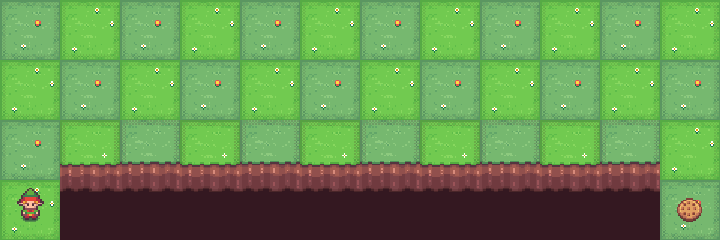

In [11]:
import java.io.File
import javax.imageio.ImageIO
import java.awt.image.BufferedImage

val first = File(recordEnv.folder).listFiles()?.sorted()?.first()?.listFiles()?.sorted()?.first()
val last = File(recordEnv.folder).listFiles()?.sorted()?.first()?.listFiles()?.sorted()?.last()

val start = ImageIO.read(first)
val finish = ImageIO.read(last)
start

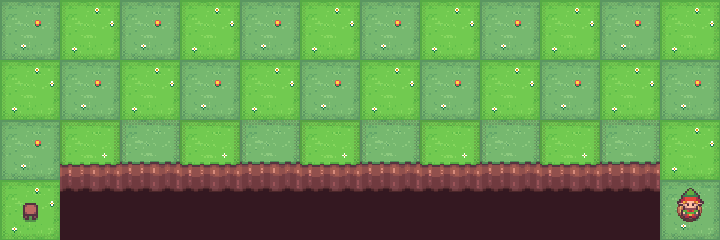

In [12]:
finish